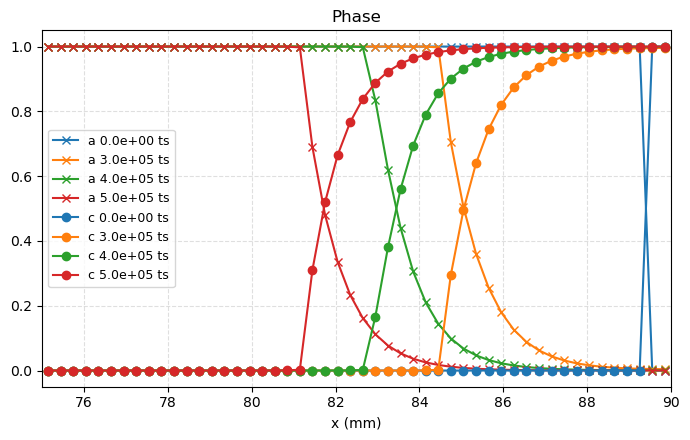

In [ ]:
import os, re
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "output"))
DX, DY = 3.0e-4, 3.0e-4  # m
DT = 1.0e-6               # s

def read_phix_field(path):
    with open(path, "rb") as f:
        header = {}
        while True:
            line = f.readline()
            if not line:
                raise IOError(f"Unexpected EOF: {path}")
            s = line.decode("ascii", errors="replace").strip()
            if s == "---":
                break
            if s.startswith("nx"):
                toks = s.split()
                header["nx"] = int(toks[1]); header["ny"] = int(toks[3]); header["nz"] = int(toks[5])
        nx, ny, nz = header["nx"], header["ny"], header["nz"]
        data = np.fromfile(f, dtype=np.float64, count=nx*ny*nz)
    return data.reshape((nz, ny, nx))[0], header  # (ny, nx)

# 要绘制的时间步
TARGET_STEPS = [0, 300000, 400000, 500000]

X_MIN_MM, X_MAX_MM = 75.0, 90.0  # 只显示此范围

fig, ax = plt.subplots(figsize=(7, 4.5))

prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = [c["color"] for c in prop_cycle]

for i, step in enumerate(TARGET_STEPS):
    path = os.path.join(OUTPUT_DIR, f"eta_{step}.field")
    arr, hdr = read_phix_field(path)
    ny, nx = arr.shape
    j_mid = ny // 2                          # 中心行索引
    x = (np.arange(nx) + 0.5) * DX * 1e3   # mm
    mask = (x >= X_MIN_MM) & (x <= X_MAX_MM)
    ax.plot(x[mask], arr[j_mid, mask], '-x', label=f"a {step:.1e} ts",color=colors[i])

for i, step in enumerate(TARGET_STEPS):
    path = os.path.join(OUTPUT_DIR, f"eta_{step}.field")
    arr, hdr = read_phix_field(path)
    ny, nx = arr.shape
    j_mid = ny // 2                          # 中心行索引
    x = (np.arange(nx) + 0.5) * DX * 1e3   # mm
    mask = (x >= X_MIN_MM) & (x <= X_MAX_MM)
    ax.plot(x[mask], 1 - arr[j_mid, mask], '-o', label=f"c {step:.1e} ts",color=colors[i])

ax.set_xlabel("x (mm)")
ax.set_title("Phase")
ax.legend(fontsize=9)
ax.set_xlim(X_MIN_MM, X_MAX_MM)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
